In [1]:
!pip install tensorflow opencv-contrib-python youtube-dl moviepy pydot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.3 MB/s eta 0:00:0000:010:01


In [2]:
!pip install -q gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 39.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 98.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.8 MB/s eta 0:00:00


In [3]:
import warnings

warnings.filterwarnings("ignore", category=SyntaxWarning)


In [4]:
import os
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
from moviepy.editor import *
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, TimeDistributed, ConvLSTM2D, MaxPooling3D, Dropout
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from google.colab.patches import cv2_imshow



2025-04-23 06:00:23.128800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745388023.325811      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745388023.379356      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_r

In [5]:
seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

Checking TRAIN_DIR: /kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split/Train
Available classes: ['Weaponized', 'Normal', 'Violence']


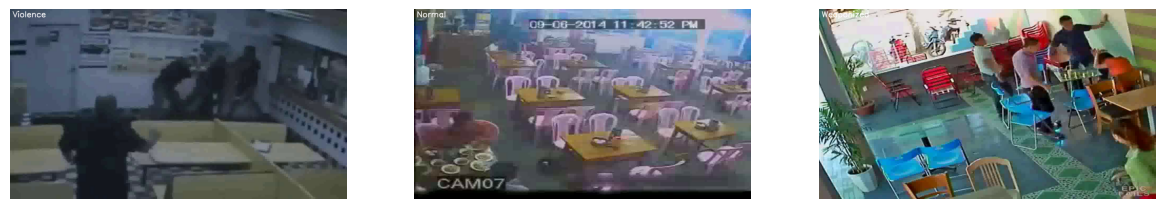

In [6]:
import os
import cv2
import random
import matplotlib.pyplot as plt
DATASET_DIR = "/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split/Train"
TRAIN_DIR = DATASET_DIR  

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")

print("Checking TRAIN_DIR:", TRAIN_DIR)
print("Available classes:", os.listdir(TRAIN_DIR))

all_classes_names = [f for f in os.listdir(TRAIN_DIR) if not f.startswith('.')]
random_range = random.sample(range(len(all_classes_names)), min(3, len(all_classes_names)))

plt.figure(figsize=(20, 20))
for counter, random_index in enumerate(random_range, 1):
    selected_class_name = all_classes_names[random_index]

    class_path = os.path.join(TRAIN_DIR, selected_class_name)
    video_files_names_list = [f for f in os.listdir(class_path) if f.endswith(('.mp4', '.avi', '.mov'))]

    if not video_files_names_list:
        print(f"No video files found in directory: {class_path}")
        continue  

    selected_video_file_name = random.choice(video_files_names_list)
    video_path = os.path.join(class_path, selected_video_file_name)

    video_reader = cv2.VideoCapture(video_path)
    success, bgr_frame = video_reader.read()
    video_reader.release()

    if not success:
        print(f"Error reading video: {video_path}")
        continue  

    rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

    cv2.putText(rgb_frame, selected_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    plt.subplot(5, 4, counter)
    plt.imshow(rgb_frame)
    plt.axis('off')

plt.show()


In [7]:
IMAGE_HEIGHT , IMAGE_WIDTH = 64, 64

SEQUENCE_LENGTH = 20

DATASET_DIR = "/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split/Train"

CLASSES_LIST = ["Normal", "Violence", "Weaponized"]


In [8]:
def frames_extraction(video_path):
    '''
    This function will extract the required frames from a video after resizing and normalizing them.
    Args:
        video_path: The path of the video in the disk, whose frames are to be extracted.
    Returns:
        frames_list: A list containing the resized and normalized frames of the video.
    '''

    frames_list = []

    video_reader = cv2.VideoCapture(video_path)

    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    skip_frames_window = max(int(video_frames_count/SEQUENCE_LENGTH), 1)

    for frame_counter in range(SEQUENCE_LENGTH):

        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        success, frame = video_reader.read()

        if not success:
            break

        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

        normalized_frame = resized_frame / 255
        frames_list.append(normalized_frame)

    video_reader.release()

    return frames_list

In [9]:
def create_dataset():

    features = []
    labels = []
    video_files_paths = []

    for class_index, class_name in enumerate(CLASSES_LIST):

        print(f'Extracting Data of Class: {class_name}')

        files_list = os.listdir(os.path.join(DATASET_DIR, class_name))

        for file_name in files_list:

            video_file_path = os.path.join(DATASET_DIR, class_name, file_name)

            frames = frames_extraction(video_file_path)

            if len(frames) == SEQUENCE_LENGTH:

                features.append(frames)
                labels.append(class_index)
                video_files_paths.append(video_file_path)

    features = np.asarray(features)
    labels = np.array(labels)

    return features, labels, video_files_paths

In [10]:
import numpy as np

features, labels, video_files_paths = create_dataset()


Extracting Data of Class: Normal
Extracting Data of Class: Violence
Extracting Data of Class: Weaponized


In [11]:
one_hot_encoded_labels = to_categorical(labels)

In [12]:
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels,
                                                                            test_size = 0.25, shuffle = True,
                                                                            random_state = seed_constant)

In [13]:
def create_convlstm_model():

    model = Sequential()


    model.add(ConvLSTM2D(filters = 4, kernel_size = (3, 3), activation = 'tanh',data_format = "channels_last",
                         recurrent_dropout=0.2, return_sequences=True, input_shape = (SEQUENCE_LENGTH,
                                                                                      IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.2)))

    model.add(ConvLSTM2D(filters = 8, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last",
                         recurrent_dropout=0.2, return_sequences=True))

    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.2)))

    model.add(ConvLSTM2D(filters = 14, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last",
                         recurrent_dropout=0.2, return_sequences=True))

    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.2)))

    model.add(ConvLSTM2D(filters = 16, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last",
                         recurrent_dropout=0.2, return_sequences=True))

    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))

    model.add(Flatten())

    model.add(Dense(len(CLASSES_LIST), activation = "softmax"))


    model.summary()

    return model

In [14]:
convlstm_model = create_convlstm_model()
print("Model Created Successfully!")

I0000 00:00:1745388607.267536      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745388607.268198      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 20, 62, 62, 4)       │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d (MaxPooling3D)         │ (None, 20, 31, 31, 4)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 20, 31, 31, 4)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 20, 29, 29, 8)       │           3,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_1 (MaxPooling3D)       │ (None, 20, 15, 15, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 20, 15, 15, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)           │ (None, 20, 13, 13, 14)      │          11,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_2 (MaxPooling3D)       │ (None, 20, 7, 7, 14)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 20, 7, 7, 14)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)           │ (None, 20, 5, 5, 16)        │          17,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_3 (MaxPooling3D)       │ (None, 20, 3, 3, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2880)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │           8,643 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,643 (162.67 KB)

 Trainable params: 41,643 (162.67 KB)

 Non-trainable params: 0 (0.00 B)

Model Created Successfully!


In [15]:
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 10, mode = 'min', restore_best_weights = True)
convlstm_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

convlstm_model_training_history = convlstm_model.fit(x = features_train, y = labels_train, epochs = 25, batch_size = 4,
                                                     shuffle = True, validation_split = 0.2,
                                                     callbacks = [early_stopping_callback])


Epoch 1/25


I0000 00:00:1745388631.557945   10831 service.cc:148] XLA service 0x7c8df4029350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745388631.558568   10831 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745388631.558585   10831 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745388633.750780   10831 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/401 ━━━━━━━━━━━━━━━━━━━━ 5:50:54 53s/step - accuracy: 0.2500 - loss: 1.0946

I0000 00:00:1745388665.625168   10831 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


401/401 ━━━━━━━━━━━━━━━━━━━━ 110s 143ms/step - accuracy: 0.3444 - loss: 1.0910 - val_accuracy: 0.5411 - val_loss: 0.9122
Epoch 2/25
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5687 - loss: 0.8965 - val_accuracy: 0.6658 - val_loss: 0.7247
Epoch 3/25
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7301 - loss: 0.6575 - val_accuracy: 0.8030 - val_loss: 0.5214
Epoch 4/25
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7928 - loss: 0.4930 - val_accuracy: 0.8105 - val_loss: 0.4651
Epoch 5/25
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8462 - loss: 0.3691 - val_accuracy: 0.7980 - val_loss: 0.5431
Epoch 6/25
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8748 - loss: 0.3221 - val_accuracy: 0.8279 - val_loss: 0.4040
Epoch 7/25
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9032 - loss: 0.2292 - val_accuracy: 0.8678 - val_loss: 0.3992
Epoch 8/25
401/401 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9289 - loss: 0.1897 - val_accur

In [16]:
model_evaluation_history = convlstm_model.evaluate(features_test, labels_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.8973 - loss: 0.3215


In [17]:
import datetime as dt
import os

# Ensure model evaluation history is correctly unpacked
if isinstance(model_evaluation_history, list) and len(model_evaluation_history) == 2:
    model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history
else:
    raise ValueError("model_evaluation_history must be a list with [loss, accuracy].")

# Format datetime for filename
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_string = dt.datetime.now().strftime(date_time_format)

# Format loss and accuracy to avoid file naming issues
model_evaluation_loss = round(model_evaluation_loss, 4)
model_evaluation_accuracy = round(model_evaluation_accuracy, 4)

# Define model filename
model_file_name = f'ConvLSTM_model__{current_date_time_string}__Loss_{model_evaluation_loss}__Accuracy_{model_evaluation_accuracy}.h5'
model_save_path = os.path.join('/kaggle/working/', model_file_name)  # Ensure it saves in the right place

# Save the model
convlstm_model.save(model_save_path)
print(f"Model saved at: {model_save_path}")


Model saved at: /kaggle/working/ConvLSTM_model__2025_04_23__06_17_23__Loss_0.2752__Accuracy_0.9163.h5


In [21]:
import os
import tensorflow as tf

# Set the dataset directory path
DATASET_DIR = "/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split"
TRAIN_DIR = os.path.join(DATASET_DIR, "Train")

# Check if the Train directory exists
if not os.path.exists(TRAIN_DIR):
    print(f"Warning: Train directory not found: {TRAIN_DIR}")
else:
    # Get all class names from the Train directory
    VIDEO_CLASSES = sorted(os.listdir(TRAIN_DIR))
    
    # Try to find the first available video from any class
    input_video_file_path = None
    for VIDEO_CLASS in VIDEO_CLASSES:
        video_class_path = os.path.join(TRAIN_DIR, VIDEO_CLASS)
        
        if not os.path.exists(video_class_path):
            print(f"Skipping class '{VIDEO_CLASS}': folder does not exist.")
            continue
        
        video_files = os.listdir(video_class_path)
        if not video_files:
            print(f"Skipping class '{VIDEO_CLASS}': no video files found.")
            continue
        
        input_video_file_path = os.path.join(video_class_path, video_files[0])
        print(f"Video file found for class '{VIDEO_CLASS}': {input_video_file_path}")
        break  # Stop after finding the first available video
    
    if input_video_file_path is None:
        print("Warning: No video files found in any class folder.")
    else:
        # Load the pre-trained ConvLSTM model
        model_path = "/kaggle/working/ConvLSTM_model__2025_04_23__06_17_23__Loss_0.2752__Accuracy_0.9163.h5"
        if not os.path.exists(model_path):
            print(f"Warning: Model file not found: {model_path}")
        else:
            model = tf.keras.models.load_model(model_path)
            print(f"Model loaded successfully from: {model_path}")


Video file found for class 'Normal': /kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted_sec_split/Train/Normal/Normal223.avi
Model loaded successfully from: /kaggle/working/ConvLSTM_model__2025_04_23__06_17_23__Loss_0.2752__Accuracy_0.9163.h5


In [19]:
import cv2
import numpy as np
from collections import deque
import tensorflow as tf

def predict_on_video(video_file_path, output_file_path, SEQUENCE_LENGTH, model, IMAGE_HEIGHT=64, IMAGE_WIDTH=64, CLASSES_LIST=None):


    if CLASSES_LIST is None:
        raise ValueError("CLASSES_LIST must be provided.")

    # Initialize the VideoCapture object to read from the video file.
    video_reader = cv2.VideoCapture(video_file_path)

    # Get video properties.
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = video_reader.get(cv2.CAP_PROP_FPS)

    # Initialize VideoWriter to save output.
    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (original_video_width, original_video_height))

    # Queue to store video frames.
    frames_queue = deque(maxlen=SEQUENCE_LENGTH)
    predicted_class_name = ""

    # Read and process video frames.
    while video_reader.isOpened():
        ok, frame = video_reader.read()
        if not ok:
            break  # Exit loop if frame is not read properly.

        # Resize and normalize frame.
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0

        # Append frame to queue.
        frames_queue.append(normalized_frame)

        # Predict when enough frames are collected.
        if len(frames_queue) == SEQUENCE_LENGTH:
            input_sequence = np.expand_dims(frames_queue, axis=0)
            predicted_probabilities = model.predict(input_sequence)[0]
            predicted_label = np.argmax(predicted_probabilities)
            predicted_class_name = CLASSES_LIST[predicted_label]

        # Overlay prediction text on video.
        cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        video_writer.write(frame)

    # Release resources.
    video_reader.release()
    video_writer.release()
    print(f"Prediction completed. Output saved at: {output_video_file_path}")


In [22]:
import os
import tensorflow as tf

# Correct model path
model_path = "/kaggle/working/ConvLSTM_model__2025_04_23__06_17_23__Loss_0.2752__Accuracy_0.9163.h5"

# Check if model file exists
if os.path.exists(model_path):
    ConvLSTM_model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully!")
else:
    raise FileNotFoundError(f"Model file not found at {model_path}")




Model loaded successfully!


In [23]:
import sys
import os
import tensorflow as tf
import cv2
import numpy as np
from collections import deque
from moviepy.editor import VideoFileClip

# Suppress TensorFlow logs (optional)
tf.get_logger().setLevel('ERROR')

# Define the directory to store test videos
test_videos_directory = '/kaggle/working/'  # Your test videos directory
os.makedirs(test_videos_directory, exist_ok=True)  # Create the directory if it does not exist

# Define input video path and sequence length
input_video_file_path = '/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted/Test/Normal/t_n002_converted.avi'

# Ensure the input video exists
if not os.path.exists(input_video_file_path):
    raise FileNotFoundError(f"Input video not found at {input_video_file_path}")

# Extract the video title (removing extension)
video_title = os.path.splitext(os.path.basename(input_video_file_path))[0]

# Load the trained ConvLSTM model
model_path = "/kaggle/working/ConvLSTM_model__2025_04_23__06_17_23__Loss_0.2752__Accuracy_0.9163.h5"

if os.path.exists(model_path):
    ConvLSTM_model = tf.keras.models.load_model(model_path)
else:
    raise FileNotFoundError(f"Model file not found at {model_path}")

# Ensure CLASSES_LIST and IMAGE_HEIGHT/IMAGE_WIDTH are defined
CLASSES_LIST = ["Normal", "Violence","Weaponized"]  # Example class list (update accordingly)
IMAGE_HEIGHT, IMAGE_WIDTH = 64, 64  # Updated to match model input size

# Get the expected sequence length from the model
expected_sequence_length = ConvLSTM_model.input_shape[1]
print(f"Expected model input sequence length: {expected_sequence_length}")

# Construct the output video path
output_video_file_path = f'{test_videos_directory}/{video_title}-Output-SeqLen{expected_sequence_length}.mp4'

def predict_on_video(video_file_path, output_file_path, SEQUENCE_LENGTH):
    video_reader = cv2.VideoCapture(video_file_path)
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = video_reader.get(cv2.CAP_PROP_FPS) or 30  # Default to 30 if FPS is None

    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc(*'mp4v'),
                                   fps, (original_video_width, original_video_height))

    frames_queue = deque(maxlen=SEQUENCE_LENGTH)
    predicted_class_name = ''

    while video_reader.isOpened():
        ok, frame = video_reader.read()
        if not ok:
            break

        resized_frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))  # Corrected to 64x64
        normalized_frame = resized_frame / 255.0
        frames_queue.append(normalized_frame)

        if len(frames_queue) == SEQUENCE_LENGTH:
            input_array = np.expand_dims(frames_queue, axis=0)
            predicted_labels_probabilities = ConvLSTM_model.predict(input_array)[0]
            predicted_label = np.argmax(predicted_labels_probabilities)
            predicted_class_name = CLASSES_LIST[predicted_label]

        cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        video_writer.write(frame)

    video_reader.release()
    video_writer.release()

# Perform action recognition with the corrected sequence length
predict_on_video(input_video_file_path, output_video_file_path, expected_sequence_length)

# Display the output video
VideoFileClip(output_video_file_path, audio=False, target_resolution=(300, None)).ipython_display()


Expected model input sequence length: 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━

Moviepy - Done !
Moviepy - video ready __temp__.mp4


In [24]:
import os
import tensorflow as tf
import cv2
import numpy as np
from collections import deque
from moviepy.editor import VideoFileClip

# ---------------------------------------------------
# NOTE: LLM functionality is mocked (no OpenAI key needed)
# ---------------------------------------------------

# Suppress TensorFlow logs
tf.get_logger().setLevel('ERROR')

# Paths configuration
test_videos_dir = '/kaggle/working/'
os.makedirs(test_videos_dir, exist_ok=True)
input_video_path = '/kaggle/input/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted/Test/Violence/t_v002_converted.avi'
model_path = '/kaggle/working/ConvLSTM_model__2025_04_23__06_17_23__Loss_0.2752__Accuracy_0.9163.h5'

# Verify files exist
if not os.path.isfile(input_video_path):
    raise FileNotFoundError(f"Input video not found: {input_video_path}")
if not os.path.isfile(model_path):
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Load pre-trained ConvLSTM model
ConvLSTM_model = tf.keras.models.load_model(model_path)
CLASSES_LIST = ["Normal", "Violence", "Weaponized"]
IMAGE_HEIGHT, IMAGE_WIDTH = 64, 64
SEQUENCE_LENGTH = ConvLSTM_model.input_shape[1]
print(f"Model expects sequence length: {SEQUENCE_LENGTH}")

# Prepare output video path
video_title = os.path.splitext(os.path.basename(input_video_path))[0]
output_video_path = os.path.join(test_videos_dir, f"{video_title}-Output-Seq{SEQUENCE_LENGTH}.mp4")

# Mock LLM alert generator (No API key needed)
def generate_alert(timestamp, activity):
    return f"alert unusual activity detected at {timestamp:.2f} seconds in video. Activity: {activity}."

# Function: process video and detect events
def predict_on_video(input_path, output_path):
    cap = cv2.VideoCapture(input_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

    queue = deque(maxlen=SEQUENCE_LENGTH)
    events = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Preprocess frame
        small = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
        norm = small.astype('float32') / 255.0
        queue.append(norm)

        label = "Normal"
        if len(queue) == SEQUENCE_LENGTH:
            inp = np.expand_dims(queue, axis=0)
            probs = ConvLSTM_model.predict(inp)[0]
            idx = int(np.argmax(probs))
            label = CLASSES_LIST[idx]
            if label != "Normal":
                ms = cap.get(cv2.CAP_PROP_POS_MSEC)
                ts = ms / 1000.0
                events.append((ts, label))

        # Overlay label
        cv2.putText(frame, label, (10, 40), cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0, 255, 0), 2)
        writer.write(frame)

    cap.release()
    writer.release()

    # After processing, print alerts
    if events:
        print("\n--- LLM Alerts ---")
        for ts, activity in events:
            alert = generate_alert(ts, activity)
            print(alert)
    else:
        print("No unusual activities detected in the video.")

# Run detection and display output video
predict_on_video(input_video_path, output_video_path)
VideoFileClip(output_video_path, audio=False, target_resolution=(300, None)).ipython_display()


Model expects sequence length: 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━

Moviepy - Done !
Moviepy - video ready __temp__.mp4


In [25]:
# ==========================================
# ✅ Add this at the END of your notebook
# ==========================================

import gradio as gr
import uuid

def run_prediction_gradio(input_video):
    input_path = input_video
    output_path = f"/kaggle/working/output_{uuid.uuid4().hex}.mp4"

    predict_on_video(
        input_path=input_path,
        output_path=output_path
    )

    return output_path

demo = gr.Interface(
    fn=run_prediction_gradio,
    inputs=gr.Video(label="Upload CCTV Video"),
    outputs=gr.Video(label="Predicted Output Video"),
    title="CCTV Activity Detection (ConvLSTM)",
    description="Upload a video to detect activity (Normal / Violence / Weaponized)."
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://5ce9bf7b1f66b859c7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━